In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm
from tqdm import tqdm
import time
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns


Mounted at /content/drive


In [ ]:
BASE_PATH     = "/content/drive/MyDrive/FinalProject/new data"
METADATA_PATH = os.path.join(BASE_PATH, "HAM10000_metadata.csv")
IMAGES_PATH   = os.path.join(BASE_PATH, "images")
MODEL_DIR     = "/content/drive/MyDrive/FinalProject/models"
BEST_MODEL_V8 = os.path.join(MODEL_DIR, "best_model_v8.pth")

os.makedirs(MODEL_DIR, exist_ok=True)

In [ ]:
df = pd.read_csv(METADATA_PATH)
df = df.dropna(subset=["image_id"]).reset_index(drop=True)

suspicious_map = {
    "mel": 1, "bcc": 1, "akiec": 1,
    "nv": 0,  "bkl": 0, "df": 0, "vasc": 0
}
df["suspicious"] = df["dx"].map(suspicious_map)

train_df = pd.read_csv("/content/drive/MyDrive/FinalProject/splits/train_df.csv")
val_df   = pd.read_csv("/content/drive/MyDrive/FinalProject/splits/val_df.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/FinalProject/splits/test_df.csv")

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 7010 | Val: 1502 | Test: 1503


In [ ]:
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(300, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [ ]:
class SkinDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["image_id"] + ".jpg")
        try:
            img = Image.open(img_path).convert("RGB")
        except:
            img = Image.fromarray(np.zeros((300,300,3), dtype=np.uint8))
        label = torch.tensor(int(row["suspicious"]), dtype=torch.long)
        if self.transform:
            img = self.transform(img)
        return img, label, row["image_id"]

train_dataset = SkinDataset(train_df, IMAGES_PATH, train_transforms)
val_dataset   = SkinDataset(val_df,   IMAGES_PATH, val_transforms)
test_dataset  = SkinDataset(test_df,  IMAGES_PATH, val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print("Loaders ready!")

Loaders ready!


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model = timm.create_model("efficientnet_b3", pretrained=True, num_classes=2).to(device)

class_weights = torch.tensor([1.0, 3.0], device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

In [ ]:
# TRAINING LOOP - V8

EPOCHS = 20

history_v8 = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_loss_v8 = float("inf")

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    start_time = time.time()

    # TRAIN
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    pbar = tqdm(train_loader, desc="Training", leave=False)

    for images, labels, _ in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{train_correct/train_total:.4f}"
        })

    scheduler.step()

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels, _ in tqdm(val_loader, desc="Validating", leave=False):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    epoch_time = time.time() - start_time

    tl = train_loss / len(train_loader)
    vl = val_loss / len(val_loader)
    ta = train_correct / train_total
    va = val_correct / val_total

    history_v8["train_loss"].append(tl)
    history_v8["val_loss"].append(vl)
    history_v8["train_acc"].append(ta)
    history_v8["val_acc"].append(va)

    if vl < best_val_loss_v8:
        best_val_loss_v8 = vl
        torch.save(model.state_dict(), BEST_MODEL_V8)
        print("Saved best_model_v8.pth")

    print(f"Train Loss: {tl:.4f} | Train Acc: {ta:.4f}")
    print(f"Val   Loss: {vl:.4f} | Val   Acc: {va:.4f}")
    print(f"Time: {epoch_time:.2f}s | LR: {scheduler.get_last_lr()[0]:.6f}")
    print("-" * 50)


Epoch 1/20


Saved best_model_v8.pth
Train Loss: 0.7732 | Train Acc: 0.7552
Val   Loss: 0.4005 | Val   Acc: 0.8722
Time: 2390.80s | LR: 0.000998
--------------------------------------------------

Epoch 2/20


Train Loss: 0.3884 | Train Acc: 0.8245
Val   Loss: 0.4580 | Val   Acc: 0.8755
Time: 27.80s | LR: 0.000994
--------------------------------------------------

Epoch 3/20


Saved best_model_v8.pth
Train Loss: 0.3275 | Train Acc: 0.8646
Val   Loss: 0.3521 | Val   Acc: 0.8828
Time: 28.24s | LR: 0.000986
--------------------------------------------------

Epoch 4/20


Train Loss: 0.3362 | Train Acc: 0.8748
Val   Loss: 0.4378 | Val   Acc: 0.8881
Time: 28.92s | LR: 0.000976
--------------------------------------------------

Epoch 5/20


...

Train Loss: 0.1146 | Train Acc: 0.9609
Val   Loss: 0.3266 | Val   Acc: 0.9141
Time: 28.11s | LR: 0.000655
--------------------------------------------------

Epoch 17/20


Train Loss: 0.0870 | Train Acc: 0.9676
Val   Loss: 0.3609 | Val   Acc: 0.9161
Time: 28.74s | LR: 0.000617
--------------------------------------------------

Epoch 18/20


Train Loss: 0.1332 | Train Acc: 0.9581
Val   Loss: 0.3291 | Val   Acc: 0.9068
Time: 29.00s | LR: 0.000578
--------------------------------------------------

Epoch 19/20


Train Loss: 0.1260 | Train Acc: 0.9541
Val   Loss: 0.4277 | Val   Acc: 0.9148
Time: 28.88s | LR: 0.000539
--------------------------------------------------

Epoch 20/20


Train Loss: 0.0729 | Train Acc: 0.9753
Val   Loss: 0.3854 | Val   Acc: 0.9208
Time: 28.90s | LR: 0.000500
--------------------------------------------------


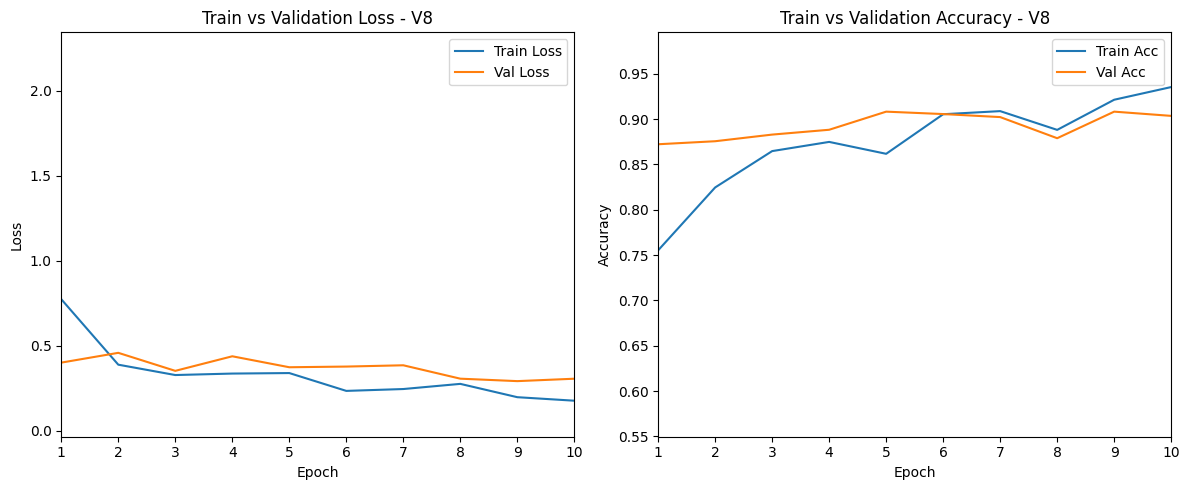

In [ ]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, history_v8["train_loss"], label="Train Loss")
plt.plot(epochs, history_v8["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss - V8")
plt.xlim(1, 10)
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, history_v8["train_acc"], label="Train Acc")
plt.plot(epochs, history_v8["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy - V8")
plt.xlim(1, 10)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# TEST EVALUATION - V8

MODEL_PATH = "/content/drive/MyDrive/FinalProject/models/best_model_v8.pth"

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

all_test_labels = []
all_test_preds  = []
all_test_probs  = []

with torch.no_grad():
    for images, labels, _ in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1)[:, 1]
        preds   = torch.argmax(outputs, dim=1)

        all_test_labels.extend(labels.cpu().numpy())
        all_test_preds.extend(preds.cpu().numpy())
        all_test_probs.extend(probs.cpu().numpy())

test_acc = accuracy_score(all_test_labels, all_test_preds)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9002


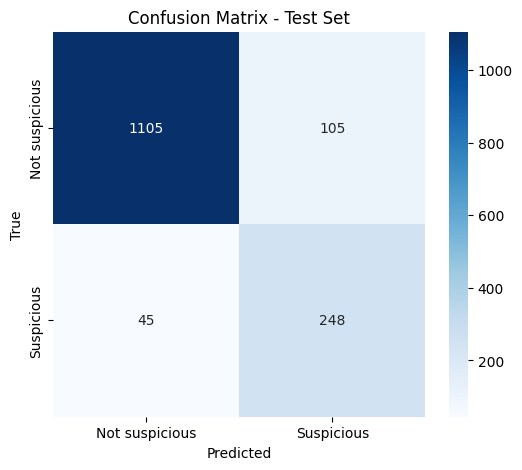

In [ ]:
cm = confusion_matrix(all_test_labels, all_test_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not suspicious", "Suspicious"],
            yticklabels=["Not suspicious", "Suspicious"])
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
print(classification_report(all_test_labels,
                            all_test_preds,
                            target_names=["Not suspicious", "Suspicious"]))

                precision    recall  f1-score   support

Not suspicious       0.96      0.91      0.94      1210
    Suspicious       0.70      0.85      0.77       293

      accuracy                           0.90      1503
     macro avg       0.83      0.88      0.85      1503
  weighted avg       0.91      0.90      0.90      1503



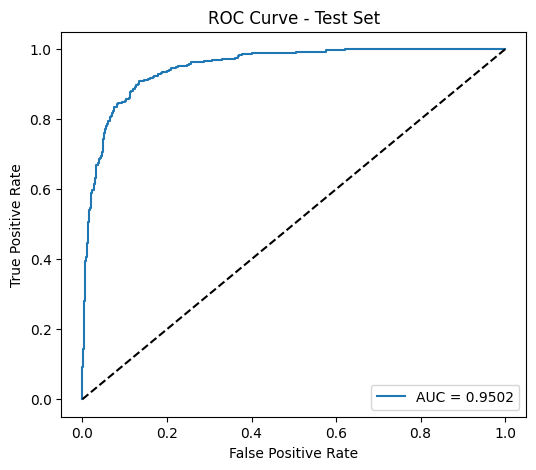

 Test ROC-AUC: 0.9502


In [ ]:
fpr, tpr, _ = roc_curve(all_test_labels, all_test_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set")
plt.legend()
plt.show()

print(f" Test ROC-AUC: {roc_auc:.4f}")

In [ ]:
fpr, tpr, thresholds = roc_curve(all_test_labels, all_test_probs)

youden_j = tpr - fpr
best_idx = youden_j.argmax()
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.4f}")
print(f"TPR: {tpr[best_idx]:.4f}, FPR: {fpr[best_idx]:.4f}")

Best threshold: 0.2644
TPR: 0.9078, FPR: 0.1347
